# Food classification in soup, salad and sandwich using Keras

## Yanis Graber, Benjamin Meyer
## March 2026
## Milestone II

## Table of Contents
1. [Project Description](#project-goals)
   - Project Goals
   - Project Motivation
2. [Data Acquisition](#data-acquisition)
   - Data Labelling
   - Data Processing
3. [Data Preparation](#training-data)
   - Training Data
   - Data Augmentation
   - Optimizing for GPU Training
4. [Model Training](#creating-the-model)
   - Creating the Model
   - Training the Model
   - Results
5. [Model Evaluation](#testing-and-evaluating-the-model)
   - Testing and Evaluating the Model
   - Confusion Matrix & F1-Score
6. [Production and Retraining](#produktion-und-retraining)
7. [Discussion and Outlook](#discussion)

## Project goals
The aim of this project is the creation of a machine learning algorithm capable of classifying foods according to the categories soup, salad and sandwich. This algorithm should be able to take images as input and categorise them according to these categories. 
For this, a number of goals needed to be achieved:
1) Aquisition of an appropriate dataset, preferrably of large size.  
2) Labeling of dataset  
3) Creation and training of algorithm
4) Designing a system of measuring the algorithms accuracy

More precicely, we wanted to learn how to use Keras, Find a suited dataset, do some preprocessing on it, choose a fitting model and finally train said model

Additionally, a further goal was choosing well-suited evaluationmetrics

## Project motivation
We chose this project due to the popular theory that any food can be classified as soup, salad or sandwich and as we were curious how such an image classification algorithm worked. Furthermore, the skills from this project could be easily applied to other machine learning applications.
The main challenges of this project are targets 3 and 4, as there exist well labelled, refined datasets of food images. Thus, the focus of this project is familiarization with keras and general machine learning workflows.  
This project uses keras, numpy and tensorflow for the algorithm and jupyter notebook as an IDE. As common with machine learning applications, it is built in Python. The most important sources are kaggle for datasets and the keras/tensorflow documentations.  
As this is a common ML exercise, there are a few similar projects such as https://github.com/rileykwok/Food-Classification.  
However, our project does not aim to reccognize specific food but rather classify them according to our defined categories. This proves challanging, as even classifying foods by hand this way can be challenging. For example, pasta and green salad are both classified as salads but look very dissimilar. However, many pasta dishes may look similar to pizza which is a sandwich.  
## Data aquisition
We sourced our data from https://www.kaggle.com/datasets/kmader/food41. The dataset contains food seperated into 101 categories with a total of 1000 images each. 
## Data labling
These categories were classified into the 3 categories and put together to form 3 large folders of foods. 
This was quite easy, as the data was already classified mroe granularly, meaning it was possible to simply put the folder for, say a club sandwich, into the sandwich category
Excact classifications can be found in the folder structure.
## Data processing
To refine data, the images were analyzed by hand and mislabled food removed. ALso removed were images where a topping or decoration obstructed the dish.
There are few things to note about the dataset. Most images are taken from a similar angle, namely from approximately 45° as if sitting at a table. Threrefore, images outside of the dataset should be taken in the same manner. As the dataset is of food, there is a large difference between foods of the same categorie. This is aggrevated by the vastly different lighting, exposure, contrast etc. of each image.


In [44]:
#18.03.2026 ML_Food_Classification, Yanis Graber & Benjamin Meyer, general structure of code was taken from online as ML projects often take the same general approach. Benjamin & Yanis: Tinkering to try getting better results, however large portions were written by Yanis as he had access to much more powerful hardware and the testing required for this large project was productive on weak hardware.


import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '4' 
import numpy as np   #needed for running model
import tensorflow as tf    #needed for running model
from tensorflow import keras    #all tensorflow imports needed for running model
from tensorflow.keras import layers
from tensorflow import data as tf_data
import matplotlib.pyplot as plt    #used for plotting results
# disable all tensorflow error logs
tf.get_logger().setLevel('ERROR')

In [12]:
image_size = (180, 180)   #Input image size
batch_size = 32    #Batch size used by model

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    "SoupSaladSandwich",
    validation_split=0.2,   #amount of images used for training/validation
    subset="both",
    seed=1337,   #seed to eliminate randomness between runs
    image_size=image_size,
    batch_size=batch_size,
)
class_names = train_ds.class_names

Found 24000 files belonging to 3 classes.
Using 19200 files for training.
Using 4800 files for validation.


# Training Data
Here is an example of the food items added to their corresponding category

In [13]:
for item in os.listdir("SoupSaladSandwich"):
    print(f"{item+':':<27}", end="")
print()
for value in range(8):
    for item in os.listdir("SoupSaladSandwich"):
        print(f"{os.listdir('SoupSaladSandwich/' + item)[value].replace('_', ' ').title():<27}", end = "")
    print()

Salad:                     Sandwich:                  Soup:                      
Beet Salad                 Club Sandwich              Clam Chowder               
Bibimbap                   Croque Madame              Creme Brulee               
Caesar Salad               Garlic Bread               French Onion Soup          
Caprese Salad              Grilled Cheese Sandwich    Hot And Sour Soup          
Greek Salad                Hamburger                  Lobster Bisque             
Pad Thai                   Hot Dog                    Miso Soup                  
Paella                     Macarons                   Pho                        
Seaweed Salad              Pulled Pork Sandwich       Ramen                      


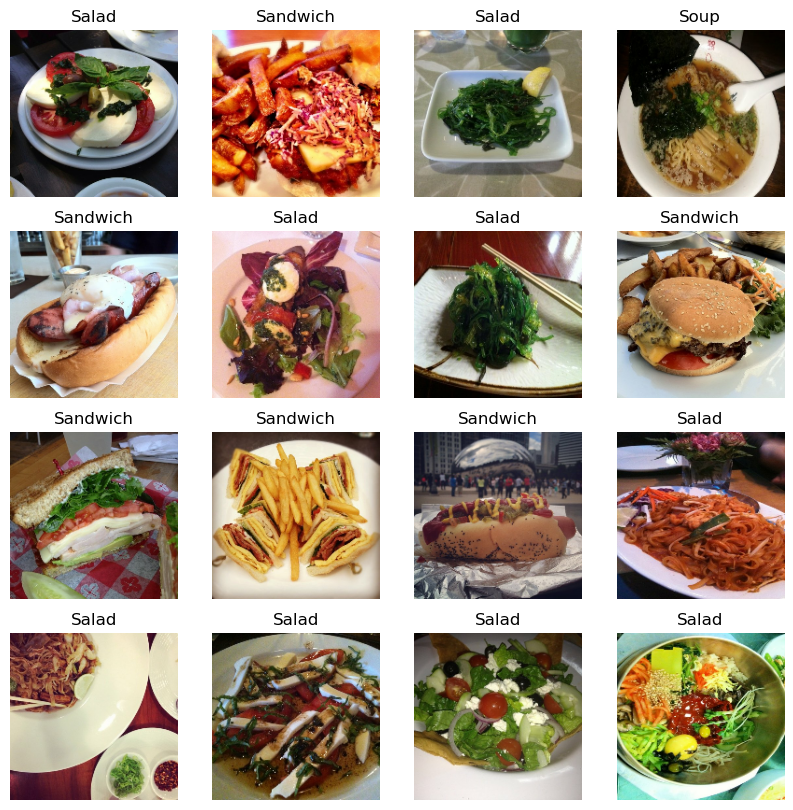

In [14]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i+1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

# Data Augmentation 
We perform various randomized alterations, like horizontally flipping, rotating and changing the brightness or contrast of the images.

In [15]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),   #random flipping
    layers.RandomRotation(0.15),    #random rotation
    layers.RandomBrightness(0.2),    #random brightness
    layers.RandomContrast(0.2),    #random contrast
]

def data_augmentation(images):  #applies data augmentation layers
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

Examples of possible data augmentations

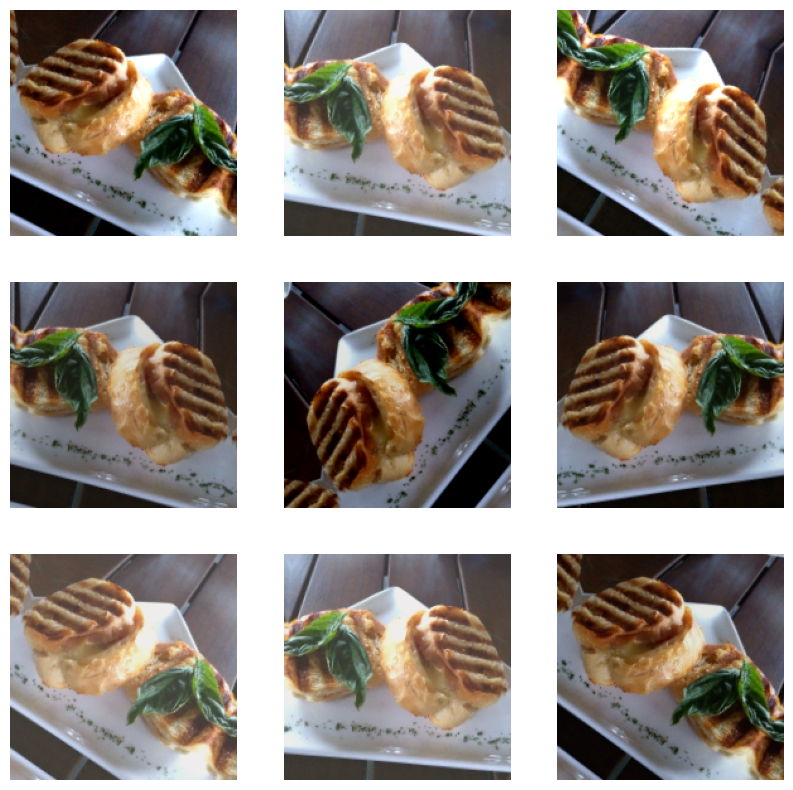

In [6]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)    
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")

# Optimizing for GPU training

In [7]:
train_ds = train_ds.map(
    lambda img, label: (data_augmentation(img), label),
    num_parallel_calls=tf_data.AUTOTUNE,
)
# Prefetching samples in GPU memory helps maximize GPU utilization.
train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)

# Creating the model
We create our model based on an exisiting pretrained image recognition model and only have to set its output classes to the amount of categories we have (3).

EfficientNetV2S is a convolutional neural network developed by Google. It achieves high accuracy and efficiency. The used version (S) is the smallest available model.
Imagenet is a large dataset containing over 1.2 million images in around 1000 categories. This was used as using a pretrained model means the algorythm already "knows" textrues, shapes etc. and leads to less training from noise, faster training and allows it to work well on smaller datasets.

In [17]:
base_model = keras.applications.EfficientNetV2S(
    include_top=False,  #removes final classification layer, allowing us to use our own classes
    weights="imagenet",   #uses pretrained weight form ImageNet
    input_shape=image_size + (3,)   #set input to 3 RGB channels
)
base_model.trainable = False   #freezes base model to preserve pretrained weights

# Defines the full classification model by adding custom layers on top of the pretrained base model
def make_model(input_shape, num_classes):
    # Define the input layer with the given image shape (180x180x3)
    inputs = keras.Input(shape=input_shape)
    # Normalize pixel values to the range expected by EfficientNetV2
    x = keras.applications.efficientnet_v2.preprocess_input(inputs)
    # Pass inputs through the frozen pretrained base model (training=False keeps
    # BatchNorm layers in inference mode, preserving pretrained statistics)
    x = base_model(x, training=False)
    # Reduce each feature map to a single value, converting 2D features to a 1D vector
    x = layers.GlobalAveragePooling2D()(x)
    # Randomly disable 25% of neurons during training to reduce overfitting
    x = layers.Dropout(0.25)(x)
    # Final layer with one output neuron per class (soup, salad, sandwich)
    outputs = layers.Dense(num_classes)(x)
    # Wrap inputs and outputs into a callable Keras model
    return keras.Model(inputs, outputs)
model = make_model(input_shape=image_size + (3,), num_classes=len(class_names))

# Training the model
We go through two different training steps, by doing a rough pass, with bigger learning steps and afterwards reduce the learning rate for fine tuning. Both steps run for about 5 epochs.

In [9]:
epochs = 5   #number of epochs
callbacks = [
    keras.callbacks.ModelCheckpoint("rough_tune_at_{epoch}.keras"),
    keras.callbacks.EarlyStopping(
        monitor="val_acc",
        patience=2,        # Stop if no improvement for 2 epochs
        restore_best_weights=True   #return to best version if accuracy drops
    ),
]

model.compile(
    optimizer=keras.optimizers.Adam(3e-4),  #optimizer with high learning rate for rough pass
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")]
    )
#train the model
rough_history = model.fit( 
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds,
)

Epoch 1/5
600/600 [==============================] - 89s 120ms/step - loss: 0.4078 - acc: 0.8599 - val_loss: 0.2502 - val_acc: 0.9104
Epoch 2/5
600/600 [==============================] - 62s 102ms/step - loss: 0.2832 - acc: 0.8967 - val_loss: 0.2251 - val_acc: 0.9179
Epoch 3/5
600/600 [==============================] - 64s 105ms/step - loss: 0.2594 - acc: 0.9055 - val_loss: 0.2121 - val_acc: 0.9217
Epoch 4/5
600/600 [==============================] - 64s 104ms/step - loss: 0.2492 - acc: 0.9121 - val_loss: 0.2089 - val_acc: 0.9233
Epoch 5/5
600/600 [==============================] - 62s 101ms/step - loss: 0.2419 - acc: 0.9131 - val_loss: 0.1985 - val_acc: 0.9260


In [10]:
epochs = 5
callbacks = [
    keras.callbacks.ModelCheckpoint("fine_tune_at_{epoch}.keras"),
    keras.callbacks.EarlyStopping(
        monitor="val_acc",
        patience=2,        # Stop if no improvement for 2 epochs
        restore_best_weights=True
    ),
]
base_model.trainable = True  #also train basemodel in fine pass

model.compile(
    optimizer=keras.optimizers.Adam(1e-5), #finer learning model
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")],
)
#fine tune model
fine_history = model.fit(
    train_ds, 
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds, 
)

Epoch 1/5
600/600 [==============================] - 162s 236ms/step - loss: 0.1837 - acc: 0.9346 - val_loss: 0.1300 - val_acc: 0.9579
Epoch 2/5
600/600 [==============================] - 141s 233ms/step - loss: 0.1213 - acc: 0.9577 - val_loss: 0.1138 - val_acc: 0.9617
Epoch 3/5
600/600 [==============================] - 140s 231ms/step - loss: 0.0871 - acc: 0.9707 - val_loss: 0.1107 - val_acc: 0.9629
Epoch 4/5
600/600 [==============================] - 143s 237ms/step - loss: 0.0656 - acc: 0.9783 - val_loss: 0.1113 - val_acc: 0.9629
Epoch 5/5
600/600 [==============================] - 143s 236ms/step - loss: 0.0482 - acc: 0.9831 - val_loss: 0.1210 - val_acc: 0.9629


# Results

In [33]:
from matplotlib import pyplot as plt
#plot accuracy and validaiton accuracy
plt.plot(rough_history.history['acc'] + fine_history.history['acc'])
plt.plot(rough_history.history['val_acc'] + fine_history.history['val_acc'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

NameError: name 'rough_history' is not defined

# Load the last trained model

In [43]:
import tensorflow as tf

model = tf.keras.models.load_model("fine_tune_at_5.keras")

ValueError: File not found: filepath=fine_tune_at_5.keras. Please ensure the file is an accessible `.keras` zip file.

# Testing and evaluating the model

In [32]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import os
import random
import math

plt.figure(figsize=(10, 10))
for i in range(9):
    # Select a random folder and image 
    folder = random.choice(os.listdir("SoupSaladSandwich"))
    subfolder = random.choice([d for d in os.listdir("SoupSaladSandwich/"+folder) if os.path.isdir(os.path.join("SoupSaladSandwich/"+folder, d))])
    file = random.choice(os.listdir("SoupSaladSandwich/"+folder+"/"+subfolder))
    # Load that image
    img = keras.utils.load_img(
        "SoupSaladSandwich/"+folder+"/"+subfolder+"/"+file,
        target_size=image_size
    )
    
    # Convert to array
    img_array = keras.utils.img_to_array(img)
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Predict
    predictions = model.predict(img_array)    
    # Convert logits to probabilities
    probabilities = tf.nn.softmax(predictions[0])
    
    ax = plt.subplot(3, 3, i+1)
    plt.imshow(np.array(img))
    title = folder.replace("_", " ").title()
    for i in range(len(probabilities)):
        title += f"\n{class_names[i]}: {np.array(probabilities)[i]*100:.2f}%"
    plt.title(title)
    plt.axis("off")


plt.subplots_adjust(bottom=0.1, right=0.8, top=0.95)

ValueError: Input 0 with name 'input_layer_1' of layer 'functional' is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(1, 180, 180, 3)

<Figure size 1000x1000 with 0 Axes>

In [17]:
from sklearn.metrics import (
    f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# Collect true labels and model predictions from the validation set
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    probs = tf.nn.softmax(preds)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(probs, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# F1-score per class and overall (macro = treats all classes equally)
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

       Salad       0.96      0.95      0.95      1573
    Sandwich       0.95      0.97      0.96      1589
        Soup       0.98      0.97      0.97      1638

    accuracy                           0.96      4800
   macro avg       0.96      0.96      0.96      4800
weighted avg       0.96      0.96      0.96      4800



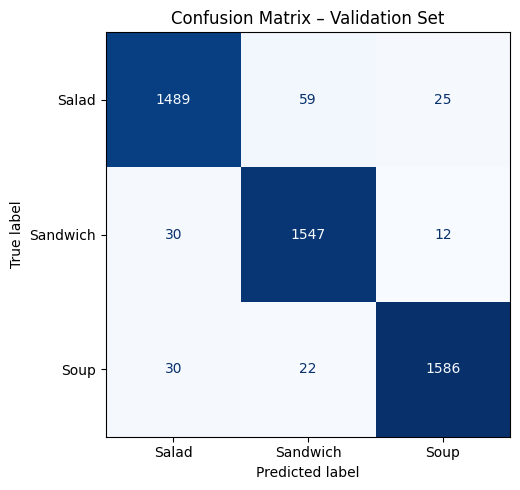

Macro F1-Score: 0.963


In [18]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix – Validation Set")
plt.tight_layout()
plt.show()

# Overall macro F1
f1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1-Score: {f1:.3f}")

In [34]:
import requests
from PIL import Image
from io import BytesIO
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Fetch the image
# Fetch a random food image from the Foodish API (no key needed)
response = requests.get("https://foodish-api.com/api/")
image_url = response.json()["image"]
print(f"Fetched: {image_url}")

response = requests.get(image_url)
img = Image.open(BytesIO(response.content)).convert("RGB")
# Preprocess to match training input
img_resized = img.resize(image_size)
img_array = keras.utils.img_to_array(img_resized)
img_array = np.expand_dims(img_array, axis=0)

# Run prediction
predictions = model.predict(img_array, verbose=0)
probabilities = tf.nn.softmax(predictions[0]).numpy()

# Display image with classification results
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
title = "Prediction:\n"
for i, name in enumerate(class_names):
    title += f"{name}: {probabilities[i]*100:.1f}%\n"
plt.title(title, fontsize=12)
plt.tight_layout()
plt.show()

Fetched: https://foodish-api.com/images/burger/burger84.jpg


ValueError: Input 0 with name 'input_layer_1' of layer 'functional' is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(1, 180, 180, 3)

# Results
All testes metrics are very high for a model that has been trained in such few epochs. The confusion matrix is very solid. 
Furthermore, there are only slight differences in scores between classes signifying a evenly trained model.

# Discussion 

In conclusion, our final scores were quite good. While we had trouble with very low accuracy in the beginning stages, we were able to largly resolve these issues in a few ways. Firstly, we used a pretrained model, which gave the model a sort of running start. We also greatly reduced the dataset to just a few very clear categories instead of using the entire dataset as before. As the classification into these 3 arbitrary clases is quite abstract, the algorythm was largly unable to reliably destinguish the food classes. With much lower variety in the dataset, the attributes of any single class was much more clear. However, this would also negatively impact the model when used outside of the foods outside the training data. A model capable of actually reasoning, why any food should be classified as a certain class would be much more flexible.
All in all, this project was a fun and interesting way of exploring some limitation of smaller neural network when applied to complex problems. The overall goal was achieved, even if the model is quite limited.

# Produktion und Retraining

## Produktion
To deploy this model in a production environment, it would be packaged as a REST API using a framework such as Flask or FastAPI. Users could then send an image via an HTTP request and receive a classification (soup, salad or sandwich) in return. The model file itself (`fine_tune_at_5.keras`) would be loaded once at startup and reused for all incoming requests. For larger scale deployment, the API would be containerized using Docker, making it easy to run consistently across different machines or cloud platforms. MLOps tools such as MLflow could be used to track model versions and manage the deployment pipeline.

## Retraining
Once deployed, the model's performance should be monitored over time. This can be done by logging predictions and periodically comparing them against manually verified ground truth labels. If accuracy drops below an acceptable threshold — for example due to new food photography styles not represented in the original training data — the model would be retrained on an expanded dataset incorporating the new examples. The retraining process would follow the same two-phase approach used here (rough pass followed by fine-tuning) and the new model version would replace the old one after passing evaluation.